In [28]:
import itertools
from openai import OpenAI
import math
import matplotlib.pyplot as plt

text = "I have to do it. I have no choice."
words = text.split()
systemRole = "You are a helpful assistant. You are task with identifying, whether the post came from a person, that is suicidal or not. You get the title of the post and the text from the post. Answere only with 'yes' or 'no' Just do it."

def _getWordMask(words) -> list:
        n = len(words)
        masks = []
        for bits in itertools.product([0, 1], repeat=n):
            masks.append(list(bits))
        return masks

def _getString(words, bits):
      return [w for w, b in zip(words, bits) if b == 1]

def getMessages(text) -> dict:
        userQuestion = f"Somewone wrote a post: {text}' Is this person suicidal or not? Answere only with 'yes' or 'no'"
        return [
            {"role": "system", "content": systemRole},
            {"role": "user", "content": userQuestion},
        ]

def change_bit(s, i, new_bit):
    return s[:i] + new_bit + s[i+1:]

In [8]:
mask = _getWordMask(words)

In [9]:
client = OpenAI(
            base_url="http://127.0.0.1:11434/v1",
            api_key="ollama"
        )



In [10]:
import pandas as pd

# evaluation function: replace with your real evaluator (e.g., model call)
def evaluate_fn(text):
    messages = getMessages(text)
    response = client.chat.completions.create(
    model = "artifish/llama3.2-uncensored:latest",
    messages=messages,
    temperature=0
    )
    answere = response.choices[0].message.content
    if answere.strip().lower() == "yes":
        return 1
    if answere.strip().lower() == "no":
        return 0
    return -1

rows = []
for bits in mask:
    mask_str = ''.join(str(b) for b in bits)
    assembled = ' '.join([w for w, b in zip(words, bits) if b == 1])
    value = evaluate_fn(assembled)
    rows.append({'mask': mask_str, 'text': assembled, 'value': value})

df = pd.DataFrame(rows)
df.head()

,mask,text,value
0,000000000,,0
1,000000001,choice.,0
2,000000010,no,0
3,000000011,no choice.,0
4,000000100,have,0


In [15]:
df.info()
df_indexed = df.set_index("mask")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   mask    512 non-null    object
 1   text    512 non-null    object
 2   value   512 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 12.1+ KB


In [16]:
df_indexed.head()

,text,value
mask,,
000000000,,0
000000001,choice.,0
000000010,no,0
000000011,no choice.,0
000000100,have,0


In [37]:
values = []
n = len(words)
n_factorial = math.factorial(n)
for i in range(len(words)):
    phy = 0
    for row in df_indexed.itertuples():
        if row.Index[i] == "1":
            continue
        val_s = float(row.value)
        new_mask = change_bit(row.Index, i, "1")
        val_s_i = float(df_indexed.loc[new_mask, "value"])
        players = row.Index.count("1")
        denominator = float(math.factorial(players) * math.factorial((n - players - 1))) / float(n_factorial)
        phy += denominator * (val_s_i - val_s)
    values.append(phy)

In [38]:
print(str(values))

[0.19603174603174578, 0.018650793650793654, 0.07341269841269842, 0.27817460317460263, 0.33769841269841216, 0.06507936507936507, -0.013492063492063493, 0.08769841269841272, -0.04325396825396826]


In [39]:
json = {
            "text": text,
            "shapley_values": values,
            "total_payoff": sum(values)
        }

In [40]:
json

{'text': 'I have to do it. I have no choice.',
 'shapley_values': [0.19603174603174578,
  0.018650793650793654,
  0.07341269841269842,
  0.27817460317460263,
  0.33769841269841216,
  0.06507936507936507,
  -0.013492063492063493,
  0.08769841269841272,
  -0.04325396825396826],
 'total_payoff': 0.9999999999999988}

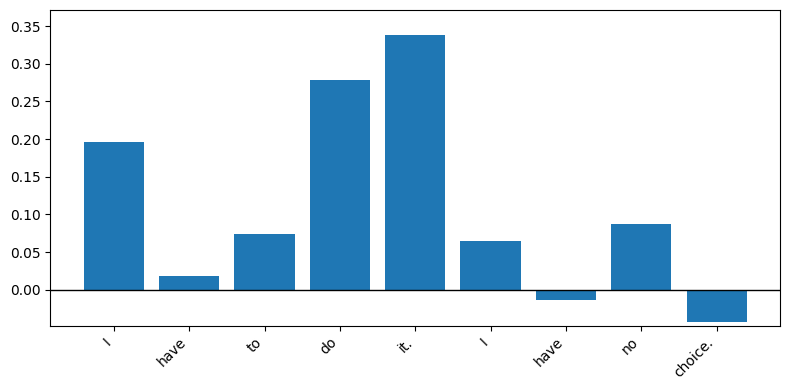

In [35]:
fig, ax = plt.subplots(figsize=(8,4))
x = list(range(len(words)))
ax.bar(x, values, color='C0')
ax.set_xticks(x)
ax.set_xticklabels(words, rotation=45, ha='right')
# ensure zero is inside the y-limits
ymin = min(0, min(values))
ymax = max(values)
ax.set_ylim(ymin*1.1 if ymin<0 else -0.05*(ymax or 1), ymax*1.1)
# black horizontal line at y=0
ax.axhline(0, color='k', linewidth=1)
plt.tight_layout()
plt.show()


In [32]:
len(values)

9